## **Data Mining Kelompok 8**
1. Hilmi Muhammad Bintang
164241004
2. Shahnaz Fatharani Azima
164241024
3. Dame Gabriela Silitonga
164241042
4. Ismanisa Ridhan Mutiarso
164241043
5. Muhammad Iqbal Aulia Fatah
164241052

## **Dataset: Predict Students' Dropout and Academic Success**
https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success



# PREPROCESSING

Prepo, EDA, dan Visualisasi EDA Data Mentah (Iqbal)

Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import re

# Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing   import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold

# SMOTE
from imblearn.over_sampling import SMOTE


# Models
from sklearn.tree         import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors    import KNeighborsClassifier
from sklearn.naive_bayes  import GaussianNB
from sklearn.svm import SVC

# Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

Load Data

In [ ]:
file_path = 'data.csv'
df = pd.read_csv(file_path, sep=';')

df.columns = (
    df.columns
    .str.replace('\t', ' ', regex=False)
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)
)

print("5 Baris Pertama Data Asli")
display(df.head())

print("\nUkuran data awal:")
print(df.shape)

5 Baris Pertama Data Asli


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate



Ukuran data awal:
(4424, 37)


Pembersihan Tipe Data

In [ ]:
print("\nMemulai Proses Pembersihan Data")

# Kolom yang kadang terbaca sebagai teks, padahal nilainya angka
object_cols = [
    'Previous qualification (grade)',
    'Admission grade',
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (grade)',
    'GDP'
]

def clean_numeric_string(val):
    if pd.isna(val):
        return np.nan

    s = str(val).strip()

    if s == "" or s.lower() in ['nan', 'none', 'null', '?']:
        return np.nan

    # Ubah koma desimal menjadi titik
    s = s.replace(',', '.')

    # Hapus karakter yang bukan angka, titik, atau minus
    s = re.sub(r'[^0-9.\-]', '', s)

    # Jika titik lebih dari satu, gabungkan bagian belakangnya
    if s.count('.') > 1:
        parts = s.split('.')
        s = parts[0] + '.' + ''.join(parts[1:])

    return pd.to_numeric(s, errors='coerce')


# Bersihkan kolom angka yang sering bermasalah
for col in object_cols:
    if col in df.columns:
        df[col] = df[col].apply(clean_numeric_string)
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Bersihkan semua kolom selain Target jika memang bisa dijadikan angka
for col in df.columns:
    if col != 'Target':
        df[col] = df[col].apply(clean_numeric_string)
        df[col] = pd.to_numeric(df[col], errors='coerce')

print("\nInformasi Dataset Setelah Pembersihan Format Angka")
df.info()


Memulai Proses Pembersihan Data

Informasi Dataset Setelah Pembersihan Format Angka
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification           

Pengecekan Missing Values & Duplikasi data

In [ ]:
missing_values = df.isnull().sum()

print("\nJumlah Missing Values per Kolom")
if missing_values[missing_values > 0].empty:
    print("Tidak ada missing value.")
else:
    display(missing_values[missing_values > 0].to_frame("Missing Values"))

duplicates = df.duplicated().sum()

print(f"\nJumlah baris duplikat: {duplicates}")


Jumlah Missing Values per Kolom
Tidak ada missing value.

Jumlah baris duplikat: 0


Feature Encoding (Target Mapping & One-Hot Encoding)

In [ ]:
# Mapping target 3 kelas
target_map = {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}
label_grafik = {0: 'Dropout', 1: 'Enrolled', 2: 'Graduate'}

print("\nDistribusi Target Sebelum Encoding")
display(df['Target'].value_counts().to_frame("Jumlah"))

df['Target'] = df['Target'].astype(str).str.strip().map(target_map)

if df['Target'].isnull().sum() > 0:
    raise ValueError("Ada nilai Target yang gagal dikonversi. Cek isi kolom Target.")

df['Target'] = df['Target'].astype(int)

# Cek apakah masih ada kolom kategorikal selain Target
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

if len(categorical_cols) > 0:
    print(f"Melakukan One-Hot Encoding pada kolom kategori: {categorical_cols}")
    df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("\nTarget berhasil diubah menjadi angka.")
display(df['Target'].map(label_grafik).value_counts().reindex(['Dropout', 'Enrolled', 'Graduate']).to_frame("Jumlah"))


Distribusi Target Sebelum Encoding


,Jumlah
Target,
Graduate,2209
Dropout,1421
Enrolled,794



Target berhasil diubah menjadi angka.


,Jumlah
Target,
Dropout,1421
Enrolled,794
Graduate,2209


Exploratory Data Analysis (EDA)

In [ ]:
# Ringkasan Statistik Data Numerik
print("\nRingkasan Statistik Data")
display(df.describe())


Ringkasan Statistik Data


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969,1.178119
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935,0.888243
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000,0.000000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000,0.000000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000,1.000000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000,2.000000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000,2.000000


Visualisasi 1: Distribusi Target (Status Mahasiswa)

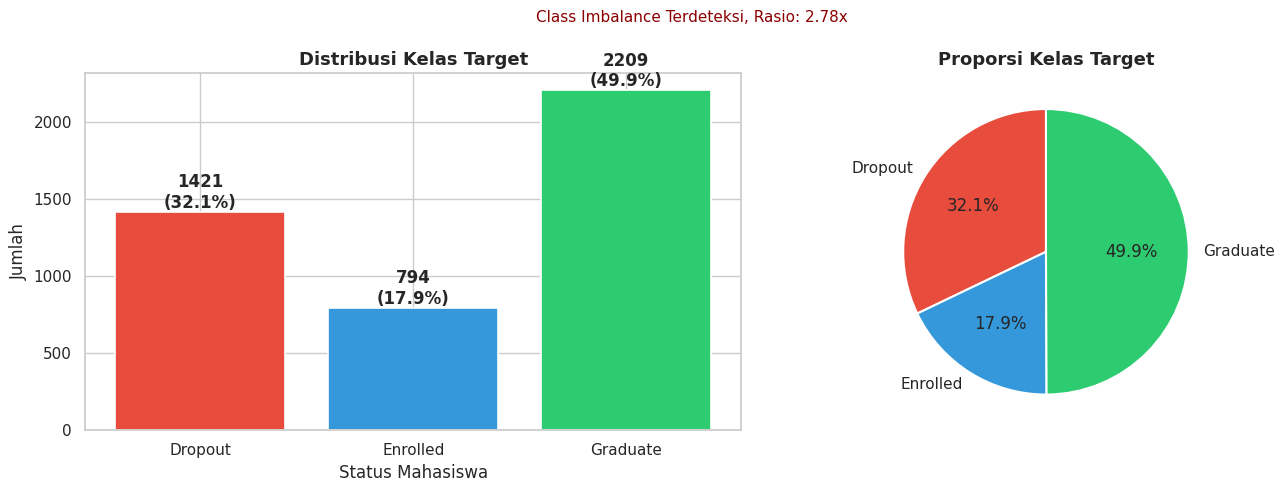

In [ ]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = df['Target'].value_counts().sort_index()
string_labels = [label_grafik[i] for i in counts.index]

colors = ['#E74C3C', '#3498DB', '#2ECC71']

bars = axes[0].bar(
    range(len(counts)),
    counts.values,
    color=colors,
    edgecolor='white',
    linewidth=1.2
)

axes[0].set_xticks(range(len(counts)))
axes[0].set_xticklabels(string_labels)

for bar, v in zip(bars, counts.values):
    pct = v / counts.sum() * 100
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{v}\n({pct:.1f}%)",
        ha='center',
        va='bottom',
        fontweight='bold'
    )

axes[0].set_title('Distribusi Kelas Target', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Status Mahasiswa')
axes[0].set_ylabel('Jumlah')

axes[1].pie(
    counts.values,
    labels=string_labels,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)

axes[1].set_title('Proporsi Kelas Target', fontsize=13, fontweight='bold')

imbalance_ratio = counts.max() / counts.min()

plt.suptitle(
    f'Class Imbalance Terdeteksi, Rasio: {imbalance_ratio:.2f}x',
    fontsize=11,
    color='darkred'
)

plt.tight_layout()
plt.savefig('1_distribusi_kelas.png', dpi=150, bbox_inches='tight')
plt.show()

Visualisasi 2: Distribusi Umur saat Pendaftaran berdasarkan Target

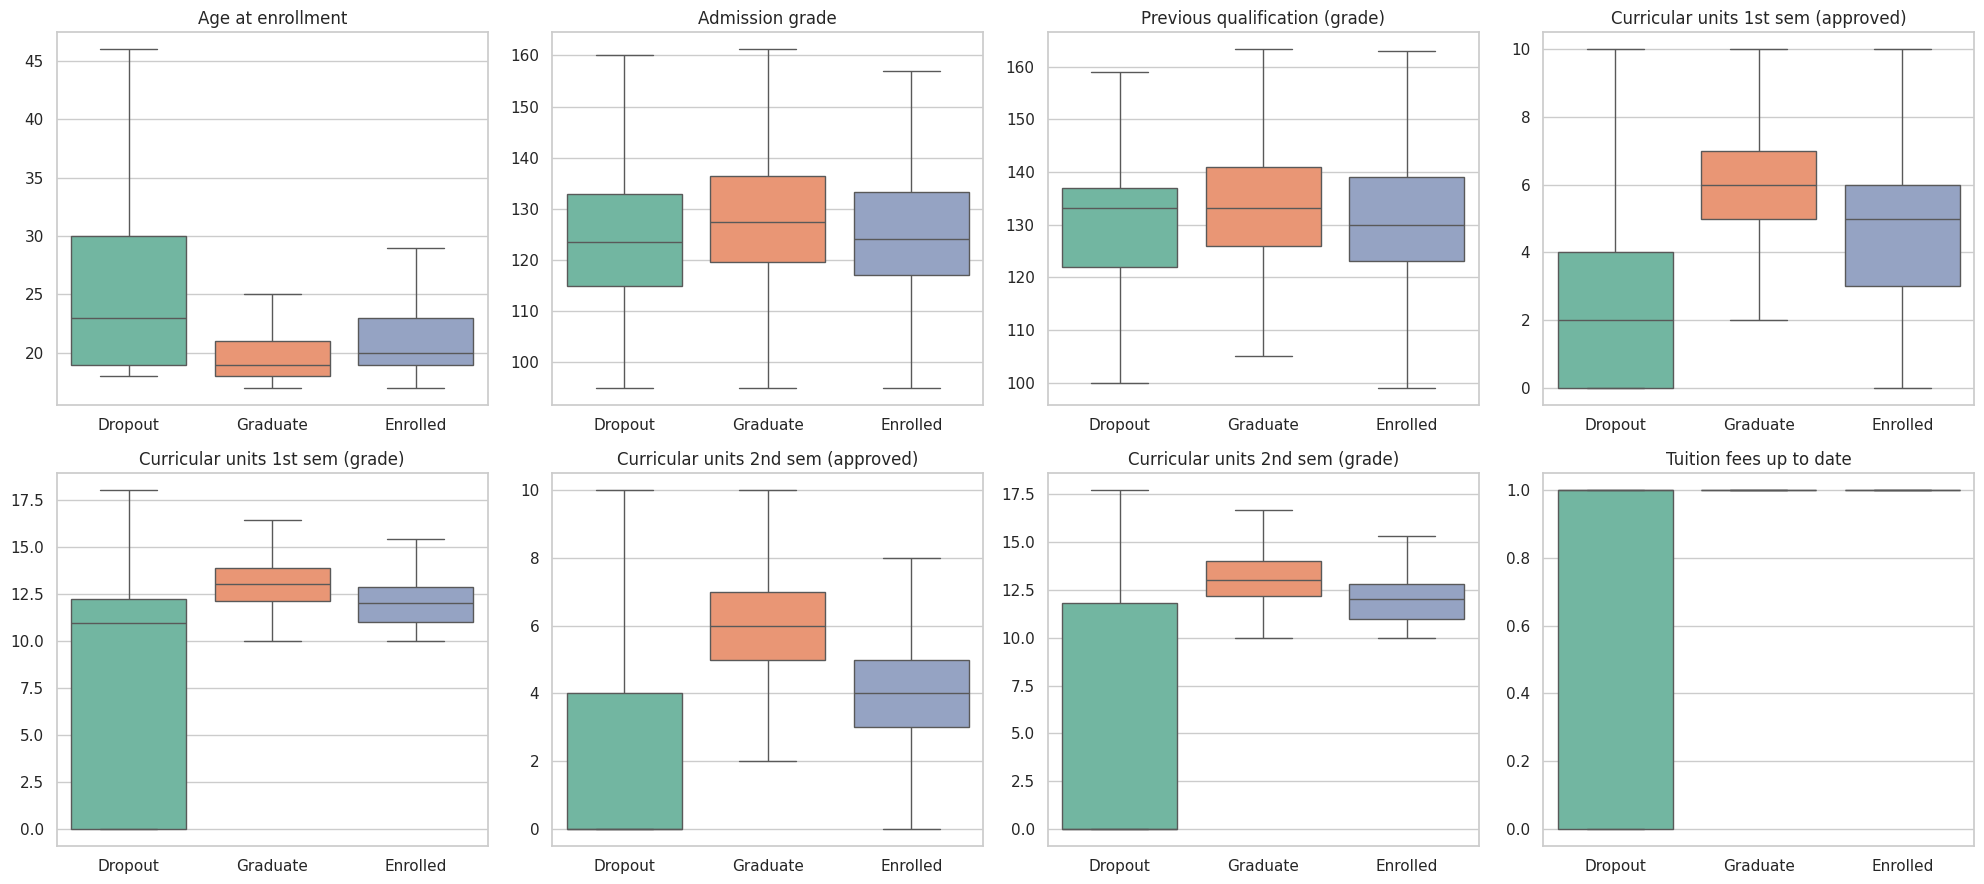

In [ ]:
fitur_penting = [
    'Age at enrollment',
    'Admission grade',
    'Previous qualification (grade)',
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)',
    'Tuition fees up to date'
]

fitur_penting = [col for col in fitur_penting if col in df.columns]

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for ax, col in zip(axes, fitur_penting):
    sns.boxplot(
        data=df,
        x=df['Target'].map(label_grafik),
        y=col,
        ax=ax,
        palette='Set2',
        showfliers=False
    )

    ax.set_title(col)
    ax.set_xlabel('')
    ax.set_ylabel('')

for ax in axes[len(fitur_penting):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

Visualisasi 3: Hubungan Nilai Masuk (Admission Grade) dengan Target

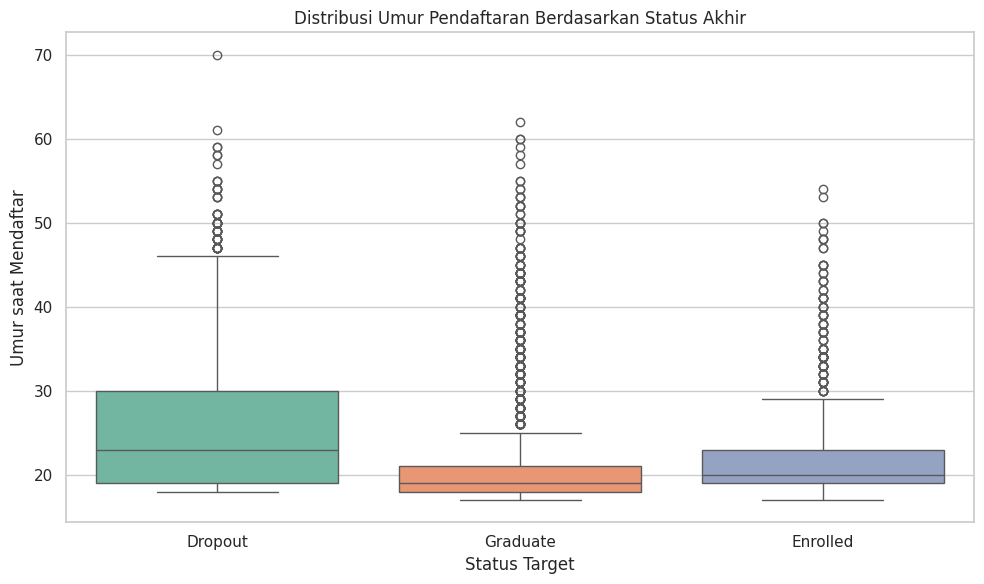

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x=df['Target'].map(label_grafik),
    y='Age at enrollment',
    palette='Set2'
)

plt.title('Distribusi Umur Pendaftaran Berdasarkan Status Akhir')
plt.xlabel('Status Target')
plt.ylabel('Umur saat Mendaftar')
plt.tight_layout()
plt.show()

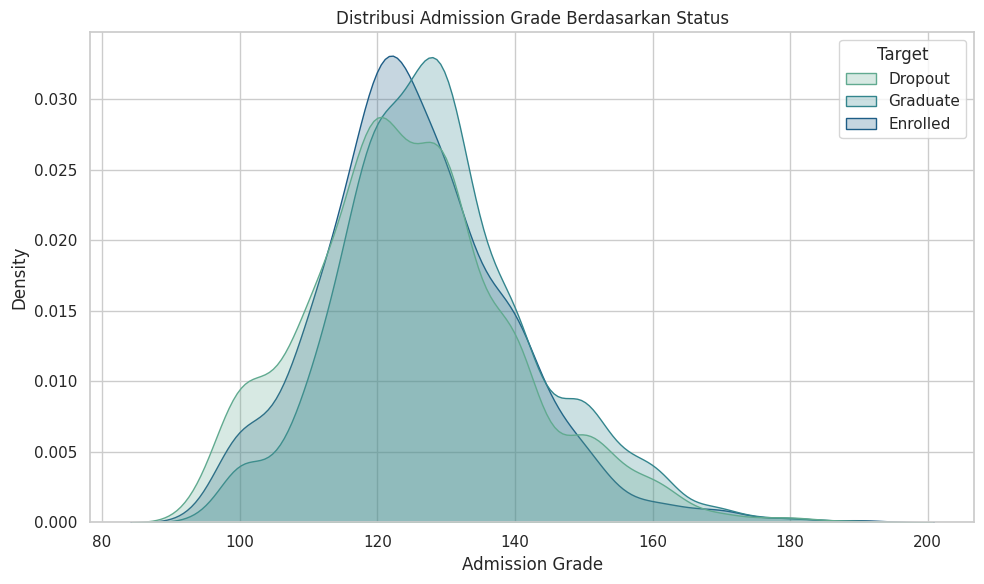

In [ ]:

plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=df,
    x='Admission grade',
    hue=df['Target'].map(label_grafik),
    fill=True,
    common_norm=False,
    palette='crest'
)

plt.title('Distribusi Admission Grade Berdasarkan Status')
plt.xlabel('Admission Grade')
plt.ylabel('Density')
plt.tight_layout()
plt.show()

Visualisasi 4: Matriks Korelasi untuk Fitur Numerik


Ringkasan Statistik Data Numerik


,count,mean,std,min,25%,50%,75%,max
Marital status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application mode,4424.0,18.669078,17.484682,1.00,1.00,17.000000,39.000000,57.000000
Application order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,8856.642631,2063.566416,33.00,9085.00,9238.000000,9556.000000,9991.000000
Daytime/evening attendance,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous qualification,4424.0,4.577758,10.216592,1.00,1.00,1.000000,1.000000,43.000000
Previous qualification (grade),4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000
Nacionality,4424.0,1.873192,6.914514,1.00,1.00,1.000000,1.000000,109.000000
Mother's qualification,4424.0,19.561935,15.603186,1.00,2.00,19.000000,37.000000,44.000000
Father's qualification,4424.0,22.275316,15.343108,1.00,3.00,19.000000,37.000000,44.000000



Top 15 Korelasi Fitur terhadap Target


,Korelasi
Curricular units 2nd sem (approved),0.624157
Curricular units 2nd sem (grade),0.566827
Curricular units 1st sem (approved),0.529123
Curricular units 1st sem (grade),0.485207
Tuition fees up to date,0.409827
Scholarship holder,0.297595
Age at enrollment,-0.243438
Debtor,-0.240999
Gender,-0.229270
Application mode,-0.221747


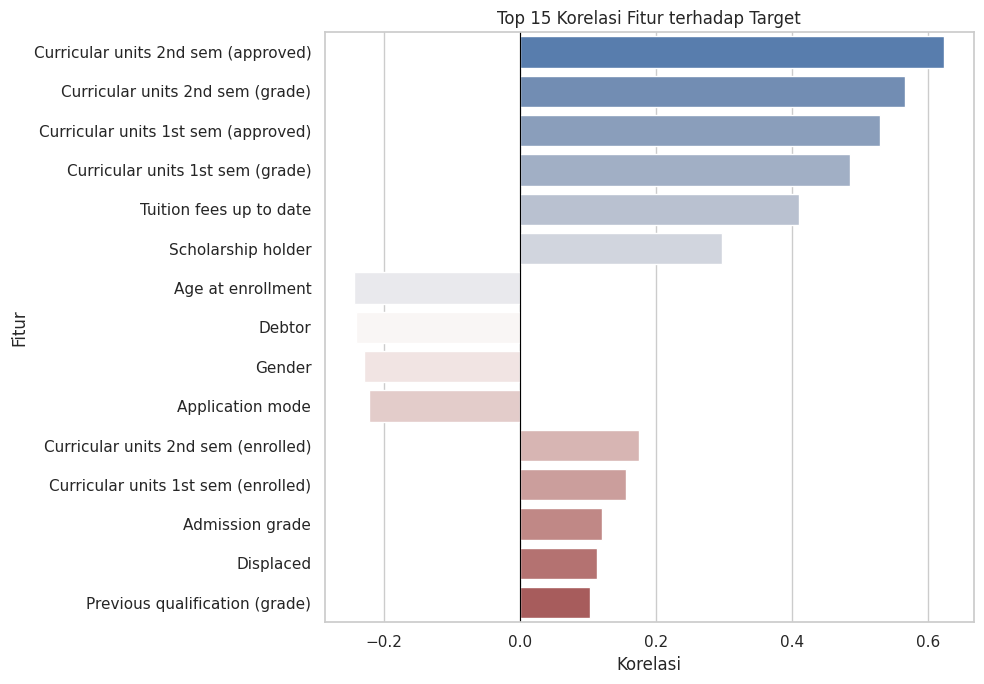

In [ ]:
numeric_cols = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_cols.corr()

target_corr = (
    correlation_matrix['Target']
    .drop('Target')
    .sort_values(key=lambda x: x.abs(), ascending=False)
    .head(15)
)

print("\nRingkasan Statistik Data Numerik")
display(df.describe().T)

print("\nTop 15 Korelasi Fitur terhadap Target")
display(target_corr.to_frame("Korelasi"))

plt.figure(figsize=(10, 7))
sns.barplot(x=target_corr.values, y=target_corr.index, palette='vlag')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 15 Korelasi Fitur terhadap Target')
plt.xlabel('Korelasi')
plt.ylabel('Fitur')
plt.tight_layout()
plt.show()

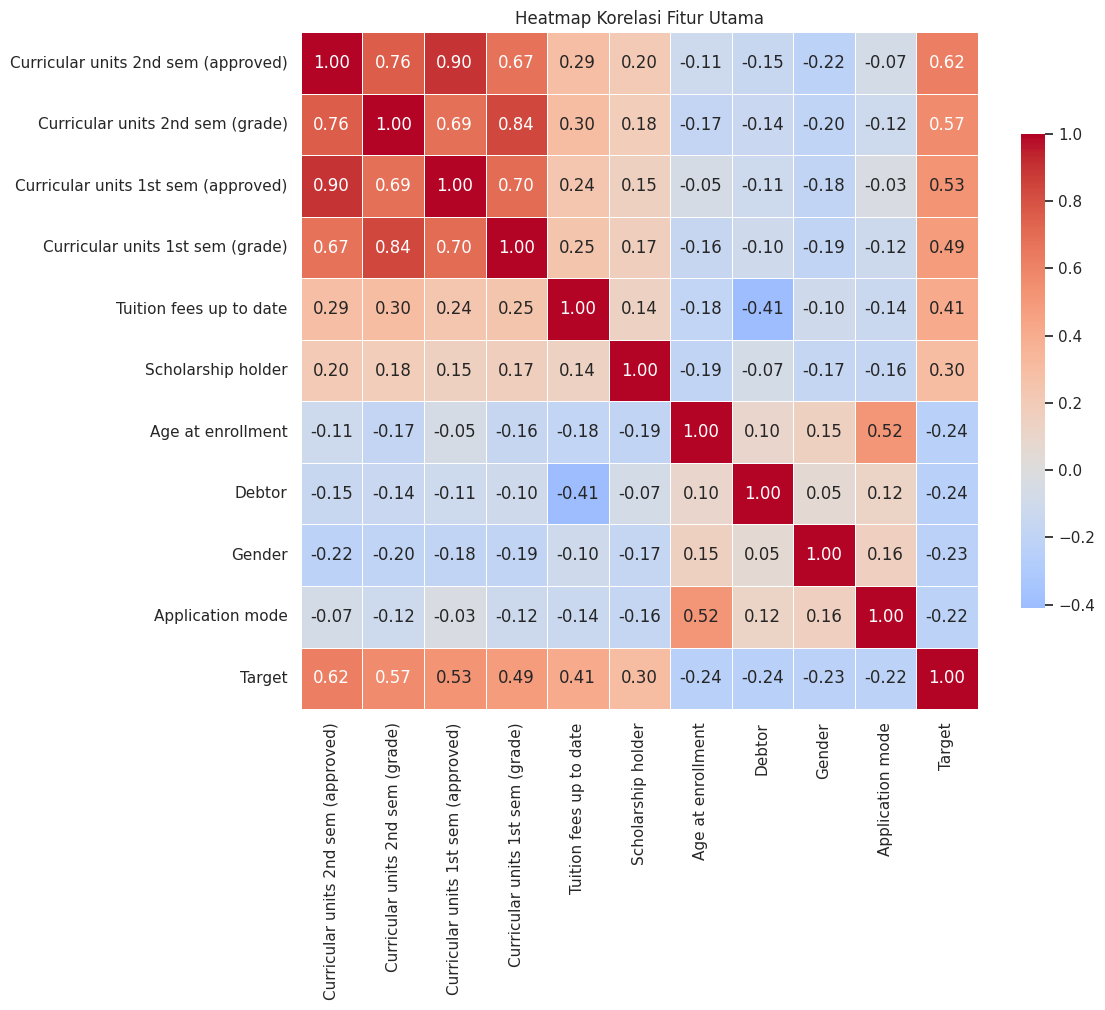

In [ ]:

top_corr_cols = target_corr.index.tolist()[:10] + ['Target']

plt.figure(figsize=(12, 10))
sns.heatmap(
    correlation_matrix.loc[top_corr_cols, top_corr_cols],
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=.5,
    cbar_kws={"shrink": .7}
)

plt.title('Heatmap Korelasi Fitur Utama')
plt.tight_layout()
plt.show()

## Label Encoding

0=Dropout, 1=Enrolled, 2=Graduate

In [ ]:
# Memisahkan fitur dan target untuk modeling
X = df.drop(columns=['Target'])
y = df['Target'].astype(int)

X_all = X.copy()
y_all = y.copy()
y_encoded = y.copy()

print("\nData Siap untuk Modeling")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"y_encoded shape: {y_encoded.shape}")

print("\nDistribusi y:")
display(
    y.map(label_grafik)
    .value_counts()
    .reindex(['Dropout', 'Enrolled', 'Graduate'])
    .to_frame("Jumlah")
)

print("\nMapping kelas:")
for kode, nama in label_grafik.items():
    print(f"  {kode} -> {nama}")

print(f"\nTotal sampel : {len(y_all)}")
print(f"Total fitur  : {X_all.shape[1]}")


Data Siap untuk Modeling
X shape: (4424, 36)
y shape: (4424,)
y_encoded shape: (4424,)

Distribusi y:


,Jumlah
Target,
Dropout,1421
Enrolled,794
Graduate,2209



Mapping kelas:
  0 -> Dropout
  1 -> Enrolled
  2 -> Graduate

Total sampel : 4424
Total fitur  : 36


# TRAIN-TEST-SPLIT

Split 80:20


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all,
    test_size=0.2,
    random_state=42,
    stratify=y_all
)

print(f'Data latih : {X_train.shape[0]} sampel (80%)')
print(f'Data uji   : {X_test.shape[0]} sampel (20%)')
print(f'\nProporsi kelas di data latih:')
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  {label_grafik[u]}: {c} ({c/len(y_train)*100:.1f}%)')

Data latih : 3539 sampel (80%)
Data uji   : 885 sampel (20%)

Proporsi kelas di data latih:
  Dropout: 1137 (32.1%)
  Enrolled: 635 (17.9%)
  Graduate: 1767 (49.9%)


## FEATURE SELECTION

### 1. MUTUAL INFORMATION

In [ ]:
categorical_features = [
    'Marital status', 'Application mode', 'Application order', 'Course',
    'Daytime/evening attendance', 'Nacionality',
    "Mother's qualification", "Father's qualification",
    "Mother's occupation", "Father's occupation",
    'Displaced', 'Educational special needs', 'Debtor',
    'Tuition fees up to date', 'Gender', 'Scholarship holder', 'International'
]
discrete_mask = [col in categorical_features for col in X_train.columns]

mi_scores = mutual_info_classif(
    X_train, y_train,
    discrete_features=discrete_mask,
    random_state=42
)
mi_df = pd.DataFrame({'Feature': X_train.columns, 'MI_Score': mi_scores})
mi_df = mi_df.sort_values('MI_Score', ascending=False).reset_index(drop=True)

### 2. RANDOM FOREST MPORTANCE

In [ ]:
rf_fs = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_fs.fit(X_train, y_train)

rf_df = pd.DataFrame({'Feature': X_train.columns, 'RF_Importance': rf_fs.feature_importances_})
rf_df = rf_df.sort_values('RF_Importance', ascending=False).reset_index(drop=True)

### VISUALISASI KEDUA METODE

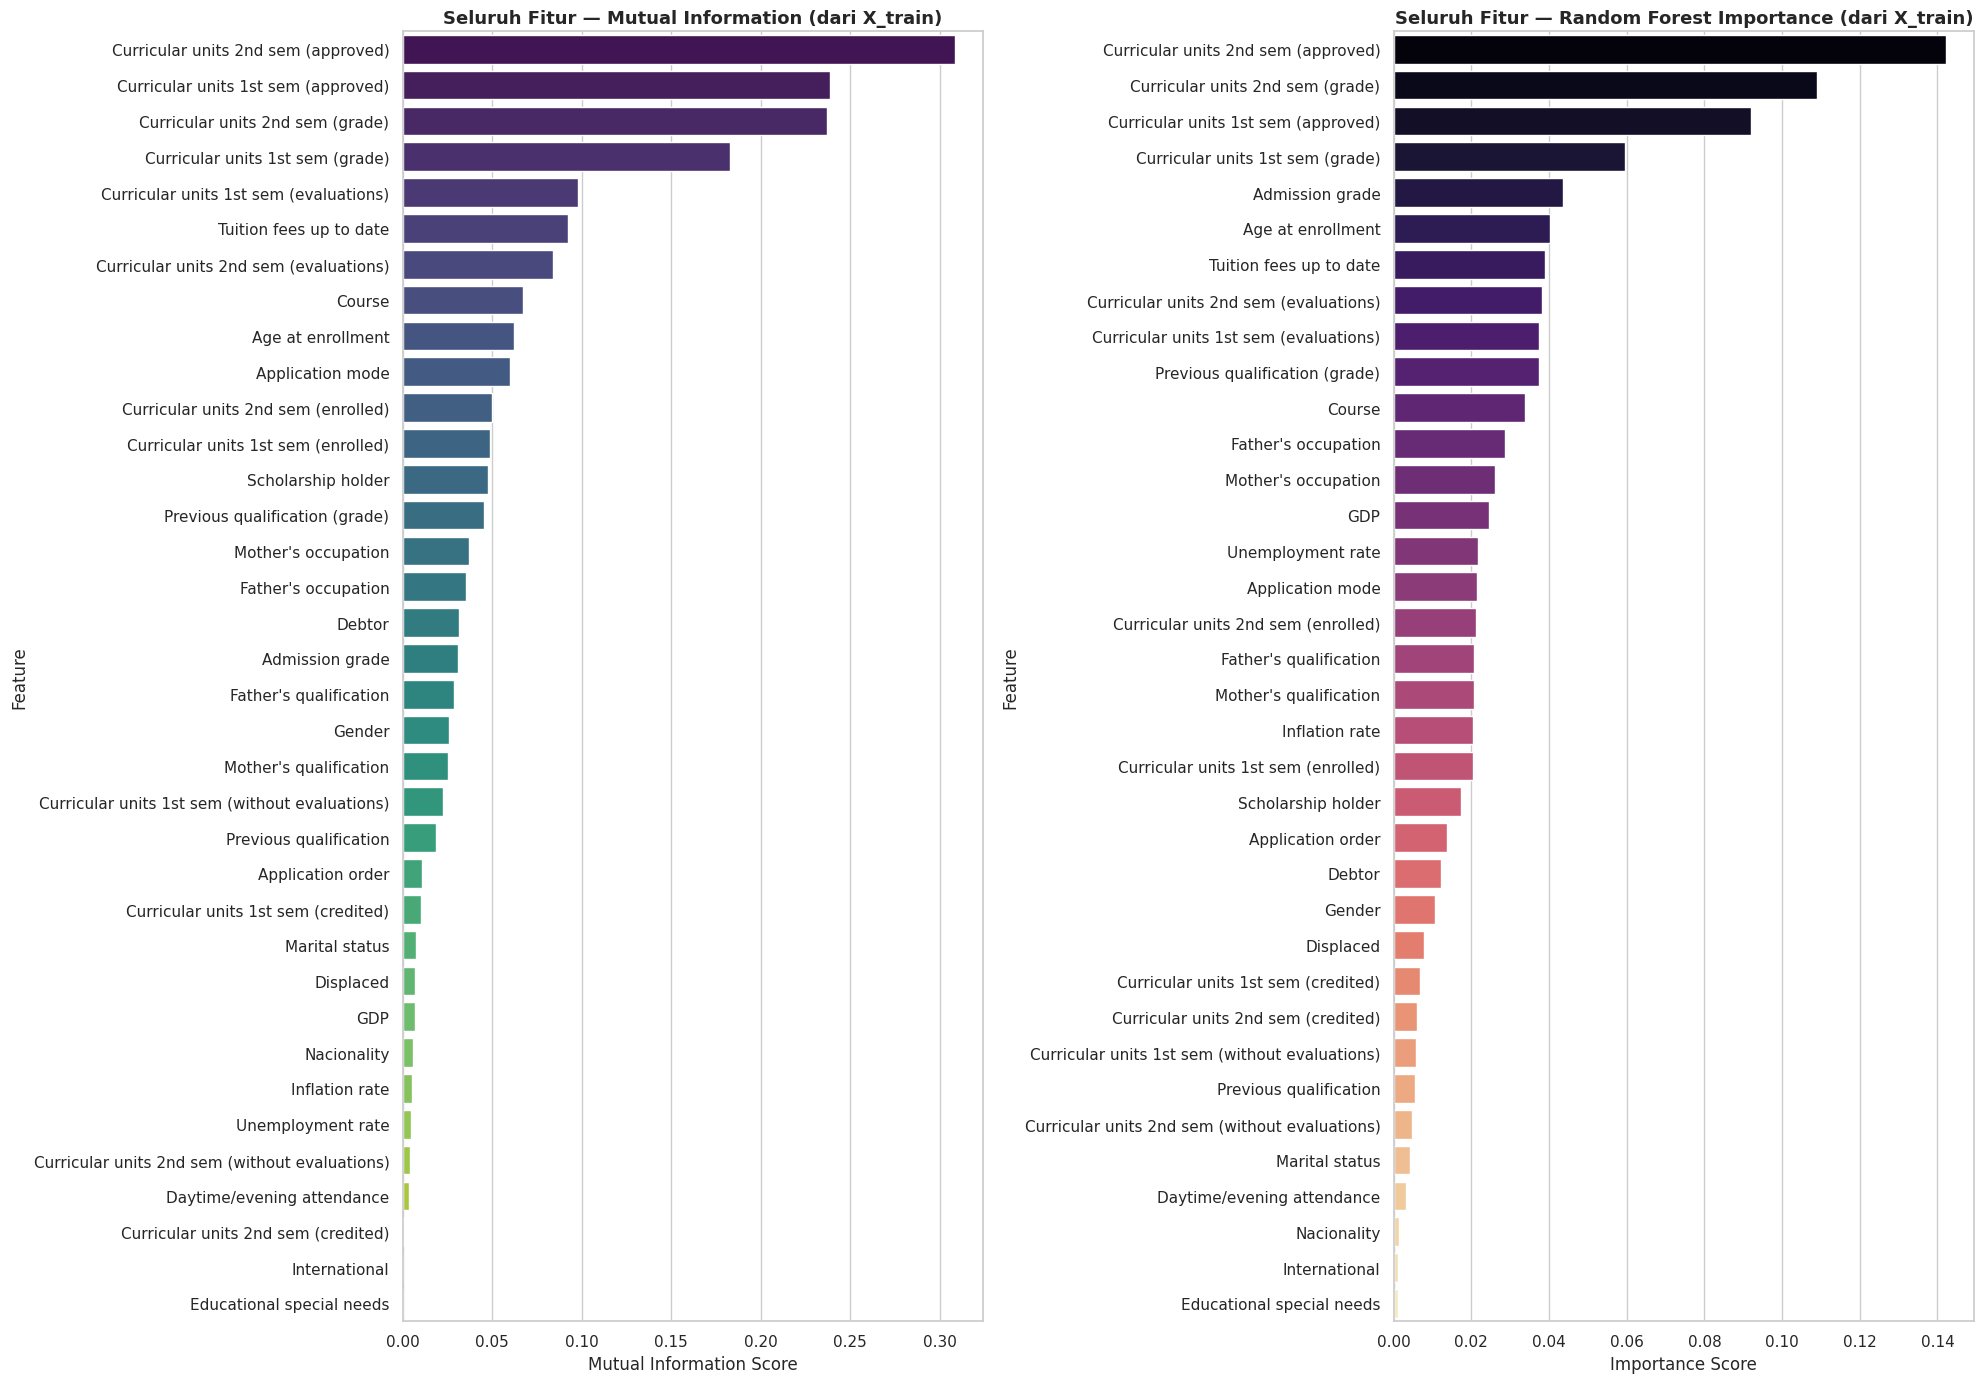

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 14))

sns.barplot(x='MI_Score', y='Feature', data=mi_df, ax=axes[0], palette='viridis')
axes[0].set_title('Seluruh Fitur — Mutual Information (dari X_train)',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Mutual Information Score')

sns.barplot(x='RF_Importance', y='Feature', data=rf_df, ax=axes[1], palette='magma')
axes[1].set_title('Seluruh Fitur — Random Forest Importance (dari X_train)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('5_feature_selection_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
TOP_N = 15

top_mi = set(mi_df.head(TOP_N)['Feature'].tolist())
top_rf = set(rf_df.head(TOP_N)['Feature'].tolist())

# Intersection
selected_features = sorted(list(top_mi & top_rf))

# Jika hasilnya kurang dari 10, tambahkan dari union
if len(selected_features) < 10:
    extra = sorted(list((top_mi | top_rf) - set(selected_features)))
    selected_features = (selected_features + extra)[:15]

print(f'Top-{TOP_N} MI : {len(top_mi)} fitur')
print(f'Top-{TOP_N} RF : {len(top_rf)} fitur')
print(f'\nFitur terpilih (konsisten di KEDUA metode): {len(selected_features)} fitur')
for i, f in enumerate(selected_features, 1):
    mi_rank = mi_df[mi_df['Feature']==f].index[0] + 1
    rf_rank = rf_df[rf_df['Feature']==f].index[0] + 1
    print(f'  {i:2d}. {f:<50s} MI=#{mi_rank:2d}  RF=#{rf_rank:2d}')

Top-15 MI : 15 fitur
Top-15 RF : 15 fitur

Fitur terpilih (konsisten di KEDUA metode): 11 fitur
   1. Age at enrollment                                  MI=# 9  RF=# 6
   2. Course                                             MI=# 8  RF=#11
   3. Curricular units 1st sem (approved)                MI=# 2  RF=# 3
   4. Curricular units 1st sem (evaluations)             MI=# 5  RF=# 9
   5. Curricular units 1st sem (grade)                   MI=# 4  RF=# 4
   6. Curricular units 2nd sem (approved)                MI=# 1  RF=# 1
   7. Curricular units 2nd sem (evaluations)             MI=# 7  RF=# 8
   8. Curricular units 2nd sem (grade)                   MI=# 3  RF=# 2
   9. Mother's occupation                                MI=#15  RF=#13
  10. Previous qualification (grade)                     MI=#14  RF=#10
  11. Tuition fees up to date                            MI=# 6  RF=# 7


In [ ]:
X_train = X_train[selected_features].copy()
X_test  = X_test[selected_features].copy()

print(f'Shape X_train setelah seleksi : {X_train.shape}')
print(f'Shape X_test  setelah seleksi : {X_test.shape}')
print(f'Fitur berkurang dari 36 → {len(selected_features)}')

Shape X_train setelah seleksi : (3539, 11)
Shape X_test  setelah seleksi : (885, 11)
Fitur berkurang dari 36 → 11


## SCALING

In [ ]:
# DT & Naive Bayes  → TIDAK perlu scaling (tidak berbasis jarak)
# KNN & LR          → WAJIB scaling (berbasis jarak / gradient)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

## SMOTE

In [ ]:
smote = SMOTE(random_state=42)
# Unscaled
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Scaled
X_train_res_sc, y_train_res_sc = smote.fit_resample(X_train_sc, y_train)

print('Distribusi kelas SETELAH SMOTE (data latih):')
unique, counts = np.unique(y_train_res, return_counts=True)

for u, c in zip(unique, counts):
    print(f'  {u}: {c}')

print(f'\nTotal sampel latih setelah SMOTE: {len(y_train_res)}')
print(f'Data uji tetap                  : {len(y_test)} sampel (tidak berubah)')

Distribusi kelas SETELAH SMOTE (data latih):
  0: 1767
  1: 1767
  2: 1767

Total sampel latih setelah SMOTE: 5301
Data uji tetap                  : 885 sampel (tidak berubah)


# MODEL

## DECISSION TREE

In [ ]:
dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid={
        'criterion'        : ['gini', 'entropy'],
        'max_depth'        : [3, 5, 7, 10, 15, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf' : [1, 2, 4]
    },
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro',
    n_jobs=-1
)
dt_grid.fit(X_train_res, y_train_res)
dt_best = dt_grid.best_estimator_

print(f'Parameter terbaik : {dt_grid.best_params_}')
print(f'CV F1-Macro    : {dt_grid.best_score_:.4f}')

Parameter terbaik : {'criterion': 'entropy', 'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2}
CV F1-Macro    : 0.7476


In [ ]:
# Prediksi pada data UJI ORIGINAL (tanpa SMOTE)
y_pred_dt = dt_best.predict(X_test)

## LOGISTIC REGRESION

In [ ]:
lr_grid = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid={
        'C'       : [0.01, 0.1, 1, 10, 100],
        'solver'  : ['lbfgs', 'saga'],
        'max_iter': [1000]
    },
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro',
    n_jobs=-1
)
lr_grid.fit(X_train_res_sc, y_train_res)
lr_best = lr_grid.best_estimator_

print(f'Parameter terbaik : {lr_grid.best_params_}')
print(f'CV F1-Macro    : {lr_grid.best_score_:.4f}')

Parameter terbaik : {'C': 1, 'max_iter': 1000, 'solver': 'lbfgs'}
CV F1-Macro    : 0.7038


In [ ]:
# Prediksi
y_pred_lr = lr_best.predict(X_test_sc)

## RANDOM FOREST

In [ ]:
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid={
        'n_estimators': [50, 100, 200],
        'max_depth': [5, 10, 15, None],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    },
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro',
    n_jobs=-1
)

rf_grid.fit(X_train_res, y_train_res)
rf_best = rf_grid.best_estimator_

print(f'Parameter terbaik : {rf_grid.best_params_}')
print(f'CV F1-Macro    : {rf_grid.best_score_:.4f}')

Parameter terbaik : {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
CV F1-Macro    : 0.8245


In [ ]:
# Prediksi
y_pred_rf = rf_best.predict(X_test)

## SVM

In [ ]:
svm_grid = GridSearchCV(
    SVC(random_state=42, probability=True),
    param_grid={
        'C': [0.1, 1, 10],
        'kernel': ['linear', 'rbf'],
        'gamma': ['scale', 'auto']
    },
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro',
    n_jobs=-1
)

svm_grid.fit(X_train_res_sc, y_train_res_sc)
svm_best = svm_grid.best_estimator_

print(f'Parameter terbaik : {svm_grid.best_params_}')
print(f'CV F1-Macro    : {svm_grid.best_score_:.4f}')

Parameter terbaik : {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
CV F1-Macro    : 0.7511


In [ ]:
# Prediksi menggunakan data test yang sudah di-scaling
y_pred_svm = svm_best.predict(X_test_sc)

# **EVALUASI**

EVALUASI MODEL: Decision Tree
Accuracy          : 0.6712
Precision Macro   : 0.6315
Recall Macro      : 0.6397
F1-score Macro    : 0.6298

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.69      0.65      0.67       284
    Enrolled       0.38      0.53      0.44       159
    Graduate       0.83      0.73      0.78       442

    accuracy                           0.67       885
   macro avg       0.63      0.64      0.63       885
weighted avg       0.70      0.67      0.68       885



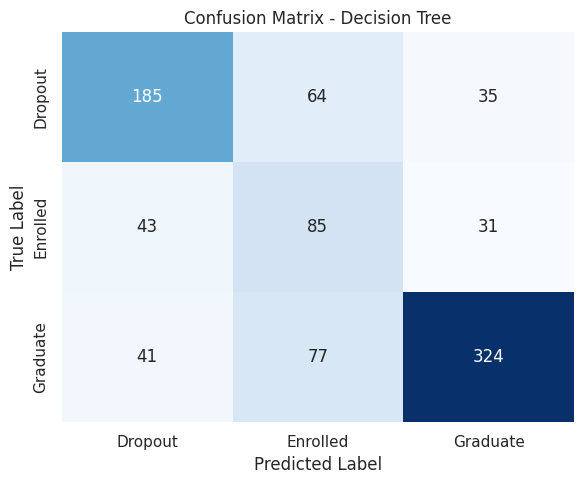

EVALUASI MODEL: Logistic Regression
Accuracy          : 0.7051
Precision Macro   : 0.6797
Recall Macro      : 0.6825
F1-score Macro    : 0.6685

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.79      0.64      0.71       284
    Enrolled       0.39      0.64      0.49       159
    Graduate       0.86      0.77      0.81       442

    accuracy                           0.71       885
   macro avg       0.68      0.68      0.67       885
weighted avg       0.75      0.71      0.72       885



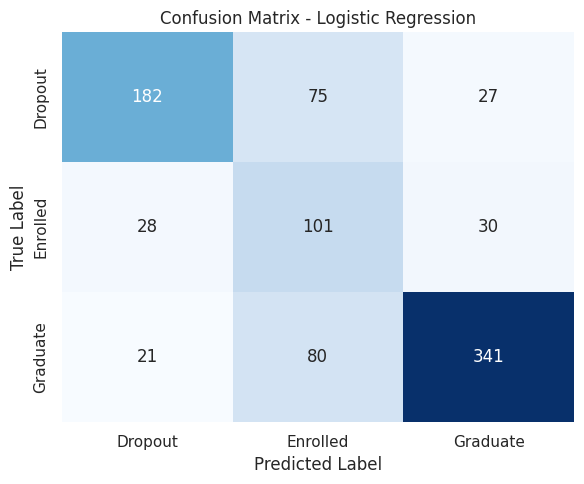

EVALUASI MODEL: Random Forest
Accuracy          : 0.7424
Precision Macro   : 0.7020
Recall Macro      : 0.7009
F1-score Macro    : 0.6963

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.82      0.68      0.74       284
    Enrolled       0.45      0.58      0.51       159
    Graduate       0.84      0.84      0.84       442

    accuracy                           0.74       885
   macro avg       0.70      0.70      0.70       885
weighted avg       0.76      0.74      0.75       885



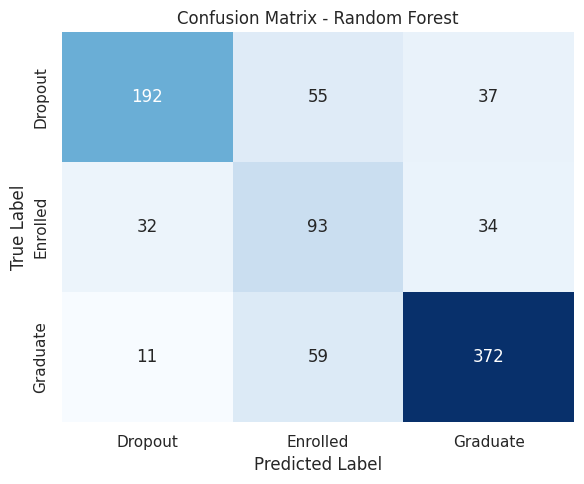

EVALUASI MODEL: SVM
Accuracy          : 0.7107
Precision Macro   : 0.6942
Recall Macro      : 0.6948
F1-score Macro    : 0.6780

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.83      0.63      0.72       284
    Enrolled       0.40      0.68      0.51       159
    Graduate       0.85      0.77      0.81       442

    accuracy                           0.71       885
   macro avg       0.69      0.69      0.68       885
weighted avg       0.76      0.71      0.73       885



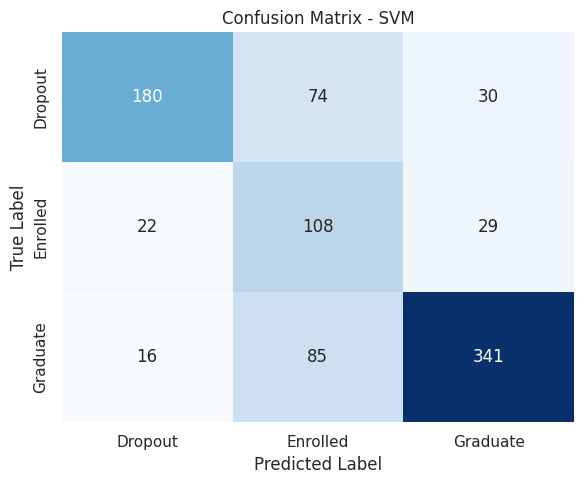


Evaluasi selesai.
Jumlah model yang dievaluasi: 4


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

label_map = {
    0: 'Dropout',
    1: 'Enrolled',
    2: 'Graduate'
}

target_names = [label_map[i] for i in sorted(label_map.keys())]

available_predictions = {}

if 'y_pred_dt' in globals():
    available_predictions['Decision Tree'] = y_pred_dt

if 'y_pred_lr' in globals():
    available_predictions['Logistic Regression'] = y_pred_lr

if 'y_pred_rf' in globals():
    available_predictions['Random Forest'] = y_pred_rf

if 'y_pred_svm' in globals():
    available_predictions['SVM'] = y_pred_svm


if 'y_test' not in globals():
    raise ValueError("Variabel y_test belum tersedia. Jalankan split dan prediksi model terlebih dahulu.")

if len(available_predictions) == 0:
    raise ValueError("Belum ada hasil prediksi model yang tersedia.")

evaluation_results = []
classification_reports = {}
confusion_matrices = {}

sns.set_theme(style="whitegrid")

for model_name, y_pred in available_predictions.items():

    if len(y_pred) != len(y_test):
        print(f"Model {model_name} dilewati karena panjang y_pred tidak sama dengan y_test.")
        print(f"len(y_pred) = {len(y_pred)}, len(y_test) = {len(y_test)}")
        continue

    acc = accuracy_score(y_test, y_pred)

    precision_macro = precision_score(y_test, y_pred, average='macro', zero_division=0)
    recall_macro = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)


    evaluation_results.append({
        'Model': model_name,
        'Accuracy': acc,
        'Precision Macro': precision_macro,
        'Recall Macro': recall_macro,
        'F1-score Macro': f1_macro
    })

    report = classification_report(
        y_test,
        y_pred,
        labels=[0, 1, 2],
        target_names=target_names,
        zero_division=0
    )

    classification_reports[model_name] = report

    cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])
    confusion_matrices[model_name] = cm

    print("=" * 70)
    print(f"EVALUASI MODEL: {model_name}")
    print("=" * 70)
    print(f"Accuracy          : {acc:.4f}")
    print(f"Precision Macro   : {precision_macro:.4f}")
    print(f"Recall Macro      : {recall_macro:.4f}")
    print(f"F1-score Macro    : {f1_macro:.4f}")

    print("\nClassification Report:")
    print(report)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=target_names,
        yticklabels=target_names,
        cbar=False
    )

    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

if len(evaluation_results) == 0:
    raise ValueError("Tidak ada model yang berhasil dievaluasi.")

print("\nEvaluasi selesai.")
print(f"Jumlah model yang dievaluasi: {len(evaluation_results)}")


TABEL PERBANDINGAN MODEL
Diurutkan berdasarkan F1-score Macro tertinggi


,Model,Accuracy,Precision Macro,Recall Macro,F1-score Macro
0,Random Forest,0.7424,0.7020,0.7009,0.6963
1,SVM,0.7107,0.6942,0.6948,0.6780
2,Logistic Regression,0.7051,0.6797,0.6825,0.6685
3,Decision Tree,0.6712,0.6315,0.6397,0.6298



Model terbaik berdasarkan F1-score Macro:
Random Forest dengan F1-score Macro = 0.6963


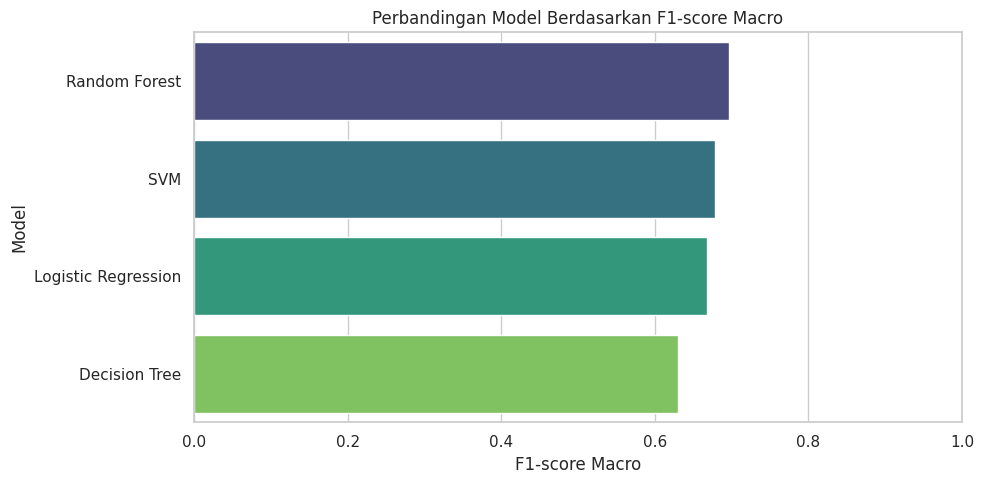


Tabel perbandingan disimpan sebagai: tabel_perbandingan_model.csv


In [ ]:
# TABEL PERBANDINGAN MODEL

comparison_df = pd.DataFrame(evaluation_results)

if comparison_df.empty:
    raise ValueError("evaluation_results masih kosong. Jalankan cell evaluasi model terlebih dahulu.")

comparison_df = (
    comparison_df
    .sort_values(by='F1-score Macro', ascending=False)
    .reset_index(drop=True)
)

print("\n" + "=" * 70)
print("TABEL PERBANDINGAN MODEL")
print("Diurutkan berdasarkan F1-score Macro tertinggi")
print("=" * 70)

format_cols = {
    'Accuracy': '{:.4f}',
    'Precision Macro': '{:.4f}',
    'Recall Macro': '{:.4f}',
    'F1-score Macro': '{:.4f}'
}

display(
    comparison_df
    .style
    .format(format_cols)
    .background_gradient(subset=['F1-score Macro'], cmap='Greens')
)

best_model = comparison_df.iloc[0]

print("\nModel terbaik berdasarkan F1-score Macro:")
print(f"{best_model['Model']} dengan F1-score Macro = {best_model['F1-score Macro']:.4f}")

plt.figure(figsize=(10, 5))
sns.barplot(
    data=comparison_df,
    x='F1-score Macro',
    y='Model',
    palette='viridis'
)

plt.title('Perbandingan Model Berdasarkan F1-score Macro')
plt.xlabel('F1-score Macro')
plt.ylabel('Model')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

comparison_df.to_csv('tabel_perbandingan_model.csv', index=False)
print("\nTabel perbandingan disimpan sebagai: tabel_perbandingan_model.csv")